<a href="https://colab.research.google.com/github/yemioz/Numerical-Methods-Projects/blob/main/Differentiation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Estimating Derivatives.

Below are imported packages that will support the functions and expressions needed for the coding throughout this project.

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Included next are declared definitions and the continuous function $4e^{-x}$ from Project Part 1.

In [ ]:
def true_error(true_value, approx_value):
   return true_value - approx_value


def relative_error(true_value, approx_value):
  return true_error(true_value, approx_value) / true_value


def approx_error(present_approx, previous_approx):
  return present_approx - previous_approx


def approx_relative_error(present_approx, previous_approx):
  return approx_error(previous_approx, present_approx) / present_approx

In [ ]:
def Taylor_Coefficient(degree, input):
  return 4*(-1)**(degree)*(math.exp((-1)*input))/(math.factorial(degree))

def Taylor_Term(degree, input):
  return Taylor_Coefficient(degree, input)*((input - 3)**(degree))

def Taylor_Polynomial(degree, input):
  sum = 0

  for i in range(0, degree + 1):
    sum = sum + Taylor_Term(i, input)
  return sum

function = lambda x: 4*math.exp(-x)

In order to continue the computing of the above continuous function, the forward difference, backward difference, central difference and finite difference are all written into functions and defined with explanatory labels.



In [ ]:
def forward_difference(function, start, step_size):
  return (function(start + step_size) - function(start))/step_size

def backward_difference(function, start, step_size):
  return (function(start) - function(start - step_size))/step_size

def central_difference(function, start, step_size):
  return (function(start + step_size) - function(start - step_size))/(2 * step_size)

def finite_difference(function, start, step_size):
  return (function(start + 2*step_size)- 2*function(start + step_size) + function(start))/step_size**2

Five different values for step sizes are declared for use in approximating answers to the actual value.

In [ ]:
center = 3
step_sizes = [1, .1 , .01, .001, .0001, .00001]

forward_approx = [forward_difference(function, center, step) for step in step_sizes]
backward_approx = [backward_difference(function, center, step) for step in step_sizes]
central_approx = [central_difference(function, center, step) for step in step_sizes]
finite_approx = [finite_difference(function, center, step) for step in step_sizes]

# exact value of first and second derivative at x=3
exact = -4*math.exp(-center)
exact_second = 4*math.exp(-center)

# error approximations
true_forward = [true_error(exact, approx) for approx in forward_approx]
relative_forward = [relative_error(exact, approx) for approx in forward_approx]

true_backward = [true_error(exact, approx) for approx in backward_approx]
relative_backward = [relative_error(exact, approx) for approx in backward_approx]

true_central = [true_error(exact, approx) for approx in central_approx]
relative_central = [relative_error(exact, approx) for approx in central_approx]

true_finite = [true_error(exact_second, approx) for approx in finite_approx]
relative_finite = [relative_error(exact, approx) for approx in finite_approx]

###Comparing values to actual values in table form.

The below four tables compare using the functions that were declared earlier. Each table shows the true error and relative error of each approximation.

**Forward Difference Approximation**

The forward difference has consistently given an underestimation.

In [ ]:
# creating forward difference approximation table
forward_data = {'Step': [step for step in step_sizes],
        'Forward Approximation': [forward for forward in forward_approx],
        'Exact': exact,
        'True Error': [error for error in true_forward],
        'Relative Error': [error for error in relative_forward]}

forward_table = pd.DataFrame(forward_data)
print(forward_table)

      Step  Forward Approximation     Exact    True Error  Relative Error
0  1.00000              -0.125886 -0.199148 -7.326256e-02        0.632121
1  0.10000              -0.189515 -0.199148 -9.633634e-03        0.951626
2  0.01000              -0.198156 -0.199148 -9.924305e-04        0.995017
3  0.00100              -0.199049 -0.199148 -9.954095e-05        0.999500
4  0.00010              -0.199138 -0.199148 -9.957081e-06        0.999950
5  0.00001              -0.199147 -0.199148 -9.957363e-07        0.999995


**Backward Difference Approximation**

The backward difference gives the best approximation for the first derivitive.

In [ ]:
# creating backward difference approximation table
backward_data = {'Step': [step for step in step_sizes],
        'Backward Approximation': [backward for backward in backward_approx],
        'True Error': [error for error in true_backward],
        'Relative Error': [error for error in relative_backward]}

backward_table = pd.DataFrame(backward_data)
print(backward_table)

      Step  Backward Approximation    True Error  Relative Error
0  1.00000               -0.342193  1.430446e-01        1.718282
1  0.10000               -0.209446  1.029779e-02        1.051709
2  0.01000               -0.200147  9.990688e-04        1.005017
3  0.00100               -0.199248  9.960734e-05        1.000500
4  0.00010               -0.199158  9.957746e-06        1.000050
5  0.00001               -0.199149  9.957457e-07        1.000005


**Central Difference Approximation**

The central difference has consistently given an overestimation.

In [ ]:
# creating central difference approximation table
central_data = {'Step': [step for step in step_sizes],
        'Central Approximation': [central for central in central_approx],
        'True Error': [error for error in true_central],
        'Relative Error': [error for error in relative_central]}

central_table = pd.DataFrame(central_data)
print(central_table)

      Step  Central Approximation    True Error  Relative Error
0  1.00000              -0.234039  3.489102e-02        1.175201
1  0.10000              -0.199480  3.320798e-04        1.001668
2  0.01000              -0.199152  3.319154e-06        1.000017
3  0.00100              -0.199148  3.319135e-08        1.000000
4  0.00010              -0.199148  3.323673e-10        1.000000
5  0.00001              -0.199148  4.712675e-12        1.000000


**Finite Difference Approximation**

In [ ]:
# creating finite difference table
finite_data = {'Step': [step for step in step_sizes],
        'Finite Approximation': [central for central in finite_approx],
        'Exact': exact_second,
        'True Error': [error for error in true_finite],
        'Relative Error': [error for error in relative_finite]}

finite_table = pd.DataFrame(finite_data)
print(finite_table)

      Step  Finite Approximation     Exact  True Error  Relative Error
0  1.00000              0.079575  0.199148    0.119573       -0.399576
1  0.10000              0.180347  0.199148    0.018801       -0.905592
2  0.01000              0.197168  0.199148    0.001980       -0.990058
3  0.00100              0.198949  0.199148    0.000199       -0.999001
4  0.00010              0.199128  0.199148    0.000020       -0.999900
5  0.00001              0.199146  0.199148    0.000002       -0.999990


###Lagrange Interpolation.

The Lagrange interpolation formula is given below:
$$\frac{(x-x_1)(x-x_2)...(x-x_n)}{(x_0-x_1)(x_0-x_2)...(x_0-x_n)}f(x_0) + \frac{(x-x_0)(x-x_2)...(x-x_n)}{(x_1-x_0)(x_1-x_2)...(x_1-x_n)}f(x_1) + ... +\frac{(x-x_1)(x-x_2)...(x-x_n)}{(x_n-x_0)(x_n-x_1)...(x_n-x_{n-1})}f(x_n)$$

Utilizing $f$ from Project Module 1, we add: $$(center, f(center))$$

$$(center + 0.1, f(center))$$

$$(2center,f(2center))$$

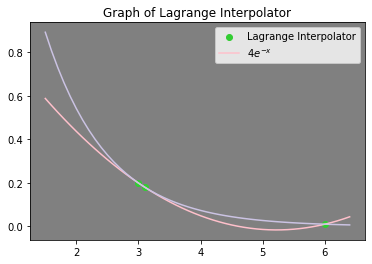

In [ ]:
def lagrange_coefficient(input, output, index, variable):
  lang_coefficient = 1
  for i in range(len(input)):
    if i == index:
      continue
    else:
      lang_coefficient = lang_coefficient*(variable - input[i])/(input[index]-input[i])
  return lang_coefficient

def lagrange_interpolator(input, output, variable):
  lang_interpolator = 0
  for i in range(len(input)):
    lang_interpolator = lang_interpolator + lagrange_coefficient(input, output, i, variable)*output[i]
  return lang_interpolator

input = [center, center+0.1, 2*center]
output = [function(value) for value in input]

x = np.arange(1.5, 6.5, .1)

ax = plt.axes()
ax.set_facecolor('grey')

plt.scatter(input ,output, c='#32cd32')
plt.plot(x, lagrange_interpolator(input, output, x), c='pink')
plt.plot(x, 4*np.exp(-x), c='#CBC3E3')
plt.title('Graph of Lagrange Interpolator')
plt.legend(['Lagrange Interpolator', '$4e^{-x}$'])

plt.show()

The ***absolute*** and the ***relative*** error is then computed for $interpolation$ at $center$ $+0.2.$

In [ ]:
# computing errors for lagrange interpolation and printing errors
lagrange_true_error = [true_error(function(center), lagrange_interpolator(input, output, center+0.2))]
lagrange_relative_error = [relative_error(function(center), lagrange_interpolator(input, output, center+0.2))]

lagrange_error_data = {'True Error': lagrange_true_error,
              'Relative Error': lagrange_relative_error}

leg_table = pd.DataFrame(lagrange_error_data)
print(leg_table)

   True Error  Relative Error
0    0.037031        0.814053


The ***absolute*** and the ***relative*** error is then computed for the $second$ $derivative$ of $interpolation$ at $center$ $+0.2.$

In [ ]:
# seperating each term of lagrange second derivative approximation
first_term = 2*output[0]/((input[0]-input[1])*(input[0]-input[2]))
second_term = 2*output[1]/((input[1]-input[0])*(input[1]-input[2]))
third_term = 2*output[2]/((input[2]-input[0])*(input[2]-input[1]))

lang_second_deriv = first_term + second_term + third_term
lang_second_deriv

true_second_error = [true_error(exact_second, lang_second_deriv)]
relative_second_error = [relative_error(exact_second, lang_second_deriv)]

second_error_data = {'True Error': true_second_error,
              'Relative Error': relative_second_error}

# printing errors in table
leg_second_table = pd.DataFrame(second_error_data)
print(leg_second_table)

   True Error  Relative Error
0     0.11195        0.437854


Since the function is constant our derivative is 0.

###Comments and Findings


In the Lagrange interpolation weighting function: $$L_i(x)=\prod_{j = 0}^{n} \frac{x-x_j}{x_i-x_j} \quad$$ where $i \neq j$, $x_i$ and $x_j$ represent the x-coordinates of the $ith$ and $jth$ points respectively.

The difference between them, $$(x_i-x_j),$$ is the distance between the points.

This formula calculates the polynomial coefficients using the Langrange basis polynomials and then evalutes the polynomial at $x$ to obtain the interpolated value.

While the findings are commented throughout the report, it's important to note the shortcomings of approximating the derivative when the continuous function is known.

When using an $h$ value, the smaller the value used gives a closer approximation... until it doesn't. When a $h$ gets ***too*** small, the $h$ value can actually move the approximation further away from the derivative.

Another shortcoming stands on the shoulders of the software operating the computers. A computer can only hold a finite amount of information. The smaller the $h$ value is used, the larger the amount of digits that are being stored. Eventually, the computer will run out of room, and mistakes (sometimes fatal) will be the consequence.